# 03 — Risco de não atingir a meta de 2025 por município

Modelo B: treinado com as features do município em 2023 para prever o resultado de 2024; o mesmo modelo é então aplicado às features de 2024 para projetar 2025 contra a `meta_alfabetizacao_2025`. A granularidade aqui é município (rede municipal), diferente do notebook 02, que opera por aluno. Este notebook apenas lê `reports/` — o retreino é feito por `python -m src.modeling.risco_municipio`.

In [1]:
import sys; sys.path.insert(0, "..")
import json
import pandas as pd

from src import config
from src.visualization import plots
from IPython.display import Image, display

pd.set_option("display.width", 160)
mb = json.loads((config.REPORTS / "metricas_modelo_b.json").read_text(encoding="utf-8"))
rank = pd.read_csv(config.REPORTS / "ranking_risco_municipios.csv")
print({k: mb[k] for k in ["n_treino", "n_com_meta", "n_indistinguivel_2024", "n_aplicacao_2024", "n_sem_meta_2025", "n_acima_da_margem", "prob_media_nao_atingir_2025"]})  # n_indistinguivel = gap dentro do ic95, conta como "atingiu" mesmo abaixo da meta

{'n_treino': 4775, 'n_com_meta': 4775, 'n_indistinguivel_2024': 2040, 'n_aplicacao_2024': 5452, 'n_sem_meta_2025': 100, 'n_acima_da_margem': 1267, 'prob_media_nao_atingir_2025': 0.20746933142862917}


## 1. Como o modelo B se saiu (RepeatedKFold 5×3, 2023 → 2024)

> **Para recordar — RepeatedKFold:** técnica de validação cruzada que divide os dados em vários blocos (*folds*), treina em uns e testa nos demais, repetindo o processo várias vezes com divisões diferentes (aqui, 5 blocos × 3 repetições) — dá uma medida de desempenho mais confiável do que um único treino/teste.

In [2]:
aval = pd.DataFrame(mb["avaliacao"])
display(aval.pivot_table(index=["tarefa", "modelo"], columns="metrica", values="media").round(3))  # só reorganiza a lista de métricas (formato longo) numa tabela tarefa x modelo, mais fácil de comparar

metrica                     brier     mae  pr_auc     r2    rmse  roc_auc
tarefa        modelo                                                     
classificacao hgb_clf       0.132     NaN   0.636    NaN     NaN    0.836
              logistica     0.125     NaN   0.630    NaN     NaN    0.843
regressao     hgb_reg         NaN   8.601     NaN  0.656  11.671      NaN
              persistencia    NaN  12.864     NaN    NaN     NaN      NaN
              ridge           NaN   8.704     NaN  0.657  11.656      NaN

Comparar com um baseline simples é um passo fácil de pular, mas evita conclusões enganosas. A **persistência** (prever que 2024 repete 2023) já é, sozinha, uma referência forte, e é a diferença de desempenho em relação ao HGB que mostra o que o contexto realmente acrescenta além de "onde o município já estava". A classificação de `nao_atingiu` tem AUC alto, mas isso não é porque o modelo é excelente — é porque a taxa atual já carrega boa parte da resposta sobre bater a meta ou não. O valor de verdade está no `gap` previsto (o tamanho da diferença), não só na classe binária de sim/não. O caso `indistinguivel` (gap dentro da margem de erro do IC) conta como "atingiu" no treino, mas é reportado à parte para não se misturar aos casos claros.

> **Para recordar:**
> - **Baseline**: um modelo ou regra simples usada como referência de comparação — se o modelo "de verdade" não supera o baseline, ele não está agregando valor.
> - **MAE (erro absoluto médio)** e **RMSE (raiz do erro quadrático médio)**: medem, em pontos percentuais, o quão longe as previsões ficam do valor real, em média. RMSE penaliza mais os erros grandes que o MAE.
> - **R² (coeficiente de determinação)**: indica que fração da variação do resultado o modelo consegue explicar — 1,0 é explicação perfeita, 0 equivale a prever sempre a média.

## 2. Ranking: cruzando risco com volume de crianças

,nome_municipio,sigla_uf,taxa_2024,ic95_2024,criancas_nao_alfabetizadas_2024,meta_2025,taxa_prevista_2025,gap_previsto_2025,prob_nao_atingir_2025,acima_da_margem,prioridade
0,Rio de Janeiro,RJ,63.76,0.46,18058.0,63.97,67.35,3.38,0.59,False,10583.04
1,Manaus,AM,50.14,0.73,12280.0,61.28,47.83,-13.45,0.85,True,10457.87
2,Salvador,BA,36.75,0.86,7661.0,52.03,37.07,-14.96,0.88,True,6728.83
3,Curitiba,PR,65.96,0.82,5403.0,73.41,64.69,-8.72,0.88,True,4730.10
4,Duque de Caxias,RJ,45.38,1.21,4510.0,57.80,43.22,-14.58,0.95,True,4292.83
5,Nova Iguaçu,RJ,33.42,1.16,5187.0,47.44,38.09,-9.35,0.62,True,3237.23
6,São Gonçalo,RJ,43.72,1.48,3186.0,56.76,42.20,-14.56,0.97,True,3089.38
7,Campo Grande,MS,51.76,0.99,5361.0,53.84,58.09,4.25,0.57,False,3053.82
8,Recife,PE,54.36,0.99,4911.0,68.08,57.32,-10.76,0.60,True,2964.54
9,São Paulo,SP,48.26,0.48,25407.0,51.06,58.61,7.55,0.11,False,2911.76


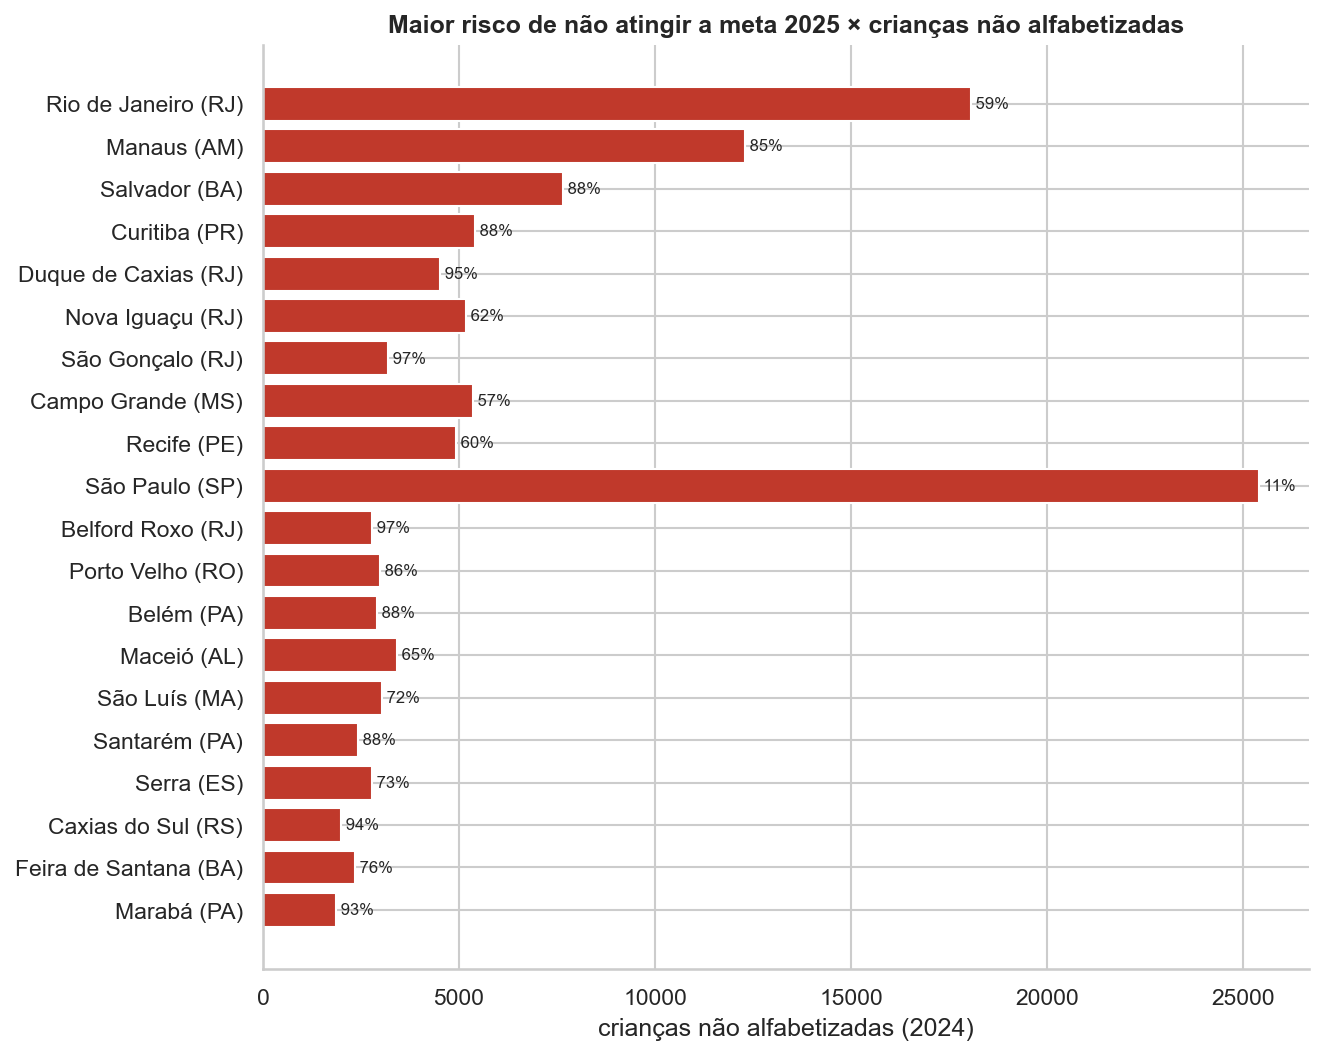

In [3]:
cols = ["nome_municipio", "sigla_uf", "taxa_2024", "ic95_2024", "criancas_nao_alfabetizadas_2024", "meta_2025", "taxa_prevista_2025", "gap_previsto_2025", "prob_nao_atingir_2025", "acima_da_margem", "prioridade"]
display(rank[cols].head(20).round(2))
caminho = plots.salvar(plots.plot_ranking_risco(rank, top=20), "ranking_risco_top20")
display(Image(filename=str(caminho)))

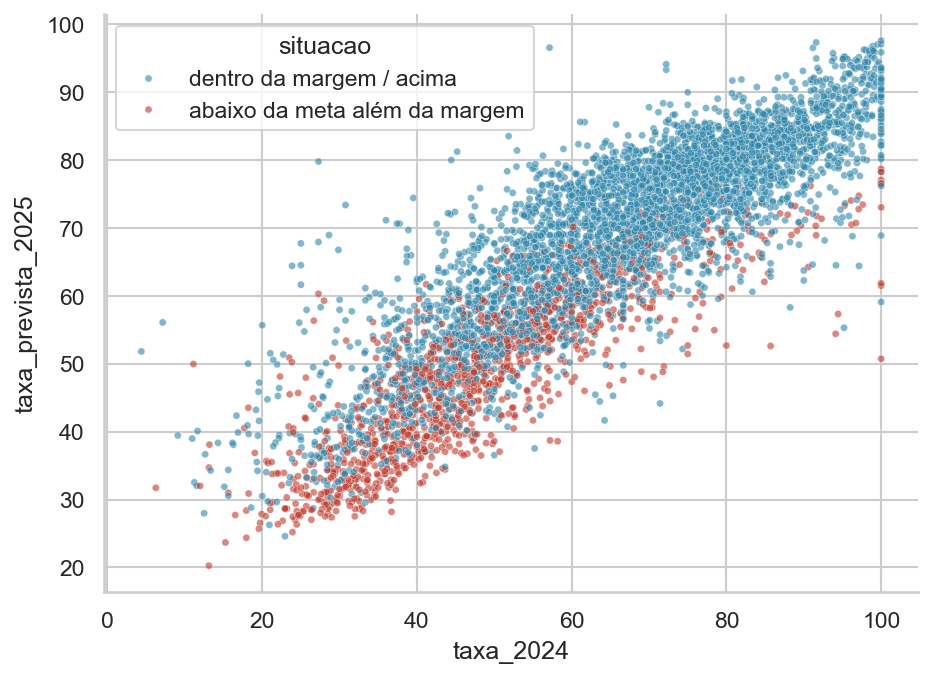

municípios previstos abaixo da meta 2025 além do ic95: 1267 de 5452
por região: {'Centro-Oeste': 4.3, 'Nordeste': 35.1, 'Norte': 33.1, 'Sudeste': 4.2, 'Sul': 35.6}


In [4]:
d = rank.dropna(subset=["meta_2025"]).assign(situacao=lambda r: r["acima_da_margem"].map({True: "abaixo da meta além da margem", False: "dentro da margem / acima"}))  # dropna tira quem não tem meta 2025 cadastrada, senão entra ponto sem sentido no gráfico
caminho = plots.salvar(plots.plot_dispersao(d, "taxa_2024", "taxa_prevista_2025", hue="situacao"), "risco_dispersao")
display(Image(filename=str(caminho)))
print(f"municípios previstos abaixo da meta 2025 além do ic95: {int(rank['acima_da_margem'].sum())} de {len(rank)}")
print("por região:", rank.groupby("regiao")["acima_da_margem"].mean().mul(100).round(1).to_dict())

## 3. Como interpretar o ranking

Ordenar apenas pela taxa prevista, do pior para o melhor, produz um ranking pouco útil na prática: municípios minúsculos com taxa muito baixa dominam o topo da lista, sem refletir onde a intervenção teria maior impacto. O critério adotado é outro:

- **Prioridade = probabilidade × crianças não alfabetizadas.** Um município pequeno com taxa péssima não lidera sozinho a lista; uma capital com taxa mediana, mas milhares de crianças fora do corte, aparece à frente — é ali que a intervenção afeta mais pessoas. Essa lógica reproduz, para 2025, o achado 2 da Fase 2.
- **`acima_da_margem`** marca apenas municípios cujo gap previsto excede o `ic95` de 2024, evitando sinalizar como "queda" uma variação que é só ruído amostral.
- **Regressão à média:** municípios que subiram muito em 2024 tendem a recuar um pouco em 2025 — comportamento normal de série temporal, não um artefato do modelo. O modelo aprende esse padrão a partir da única transição observável no treino, 2023 → 2024; a validação definitiva só será possível quando os dados de 2025 estiverem disponíveis.
- **Risco, não atribuição de responsabilidade.** O ranking aponta onde o esforço tem maior potencial de impacto, não quem "errou".